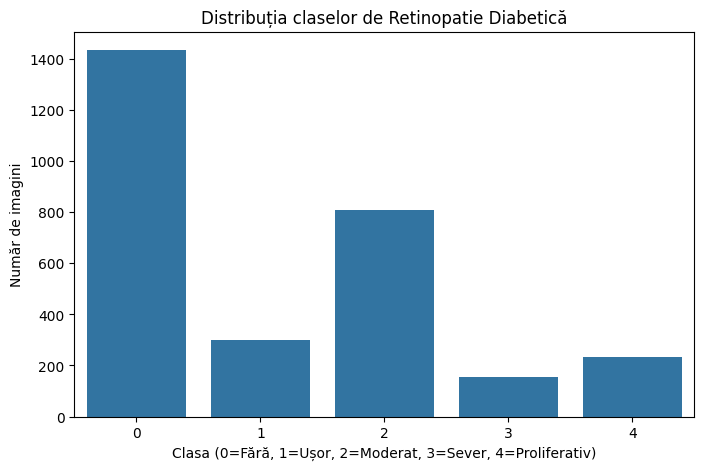

Numărul total de imagini: 2930
Numărul de imagini pe clasă:
diagnosis
0    1434
2     808
1     300
4     234
3     154
Name: count, dtype: int64


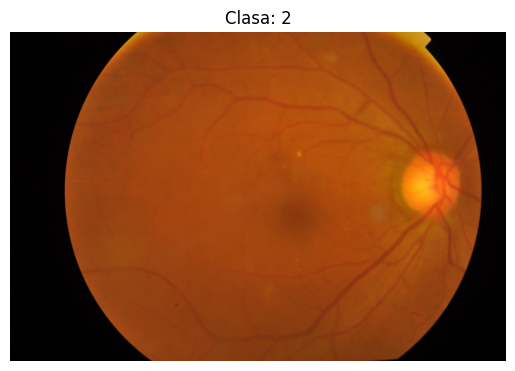

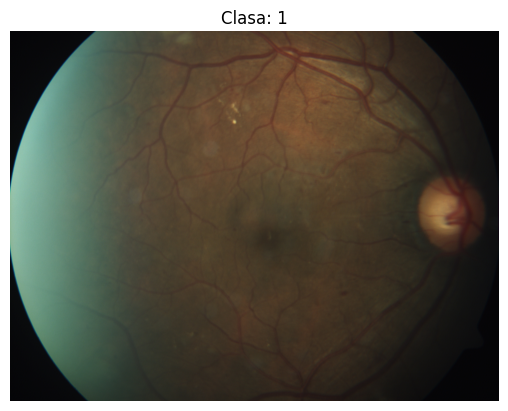

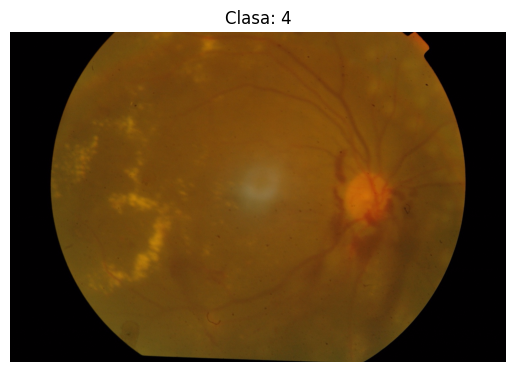

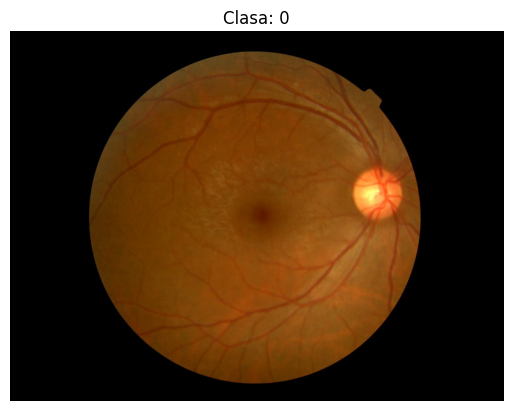

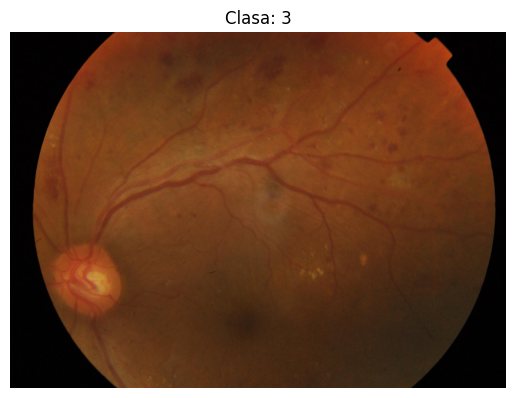

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Presupunem că ai descărcat fișierul train.csv din setul APTOS
df = pd.read_csv('Datasets/Dataset_APTOS_2019/train_1.csv')

# Vizualizarea distribuției claselor
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribuția claselor de Retinopatie Diabetică')
plt.xlabel('Clasa (0=Fără, 1=Ușor, 2=Moderat, 3=Sever, 4=Proliferativ)')
plt.ylabel('Număr de imagini')
plt.show()

# Afiseaza numarul de imagini si cate o imagine pentru fiecare clasa
print("Numărul total de imagini:", len(df))
print("Numărul de imagini pe clasă:")
print(df['diagnosis'].value_counts())
# Afișează o imagine pentru fiecare clasă
import matplotlib.image as mpimg
for diagnosis in df['diagnosis'].unique():
    img_path = df[df['diagnosis'] == diagnosis]['id_code'].iloc[0] + '.png'
    img = mpimg.imread('Datasets/Dataset_APTOS_2019/train_images/train_images/' + img_path)
    plt.imshow(img)
    plt.title(f'Clasa: {diagnosis}')
    plt.axis('off')
    plt.show()

In [75]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class DiabeticRetinopathyDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Extragem numele imaginii și eticheta
        img_name = str(self.dataframe.iloc[idx, 0]) + '.png'
        img_path = os.path.join(self.image_dir, img_name)
        
        # Încărcare imagine RGB
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        return image, label

# Transformări pentru antrenare (Augmentare)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # Standard ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Transformări pentru validare/testare
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [76]:
# Citirea fișierelor CSV
train_df = pd.read_csv('Datasets/Dataset_APTOS_2019/train_1.csv')
val_df = pd.read_csv('Datasets/Dataset_APTOS_2019/valid.csv')
test_df = pd.read_csv('Datasets/Dataset_APTOS_2019/test.csv')

# Crearea Dataset-urilor
train_dataset = DiabeticRetinopathyDataset(train_df, 'Datasets/Dataset_APTOS_2019/train_images/train_images', transform=train_transforms)
val_dataset = DiabeticRetinopathyDataset(val_df, 'Datasets/Dataset_APTOS_2019/val_images/val_images', transform=eval_transforms)
test_dataset = DiabeticRetinopathyDataset(test_df, 'Datasets/Dataset_APTOS_2019/test_images/test_images', transform=eval_transforms)

# Crearea DataLoader-elor
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8)

print(f"Imagini Antrenare: {len(train_dataset)} | Validare: {len(val_dataset)} | Testare: {len(test_dataset)}")

Imagini Antrenare: 2930 | Validare: 366 | Testare: 366


In [77]:
import torchvision.models as models
import torch.nn as nn

def create_model(num_classes=5):
    # Încărcăm modelul pre-antrenat pe ImageNet
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # Înghețăm straturile de bază (opțional, dar recomandat inițial)
    for param in model.parameters():
        param.requires_grad = False
        
    # Modificăm ultimul strat Fully Connected
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    
    # Deblocăm ultimul strat pentru a învăța
    for param in model.fc.parameters():
        param.requires_grad = True
        
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model().to(device)
print(f"Modelul rulează pe: {device}")

Modelul rulează pe: cuda


In [78]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [79]:
from sklearn.model_selection import train_test_split
import torch.optim as optim
from tqdm import tqdm

# Funcția de Loss și Optimizatorul
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

EPOCHS = 100
best_val_acc = 0.0
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# BUCLA DE ANTRENARE ȘI VALIDARE
for epoch in range(EPOCHS):
    # --- Faza de Antrenare ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    train_accuracies.append(train_acc)
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # --- Faza de Validare ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    val_accuracies.append(val_acc)
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Salvarea celui mai bun model bazat strict pe datele de validare
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_dr_model.pth')
        print(">>> Nou model de top salvat!")
    val_accuracies.append(val_acc)
    print(f"Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    # Salvăm cel mai bun model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_dr_model.pth')
        print("Model salvat!")


Epoch 1/100


Training: 100%|██████████| 92/92 [00:34<00:00,  2.69it/s]


Train Loss: 1.1609 | Train Acc: 59.52%
Val Loss: 1.0073 | Val Acc: 69.95%
>>> Nou model de top salvat!
Loss: 1.1609 | Train Acc: 59.52% | Val Acc: 69.95%

Epoch 2/100


Training: 100%|██████████| 92/92 [00:37<00:00,  2.44it/s]


Train Loss: 0.8643 | Train Acc: 70.55%
Val Loss: 0.8651 | Val Acc: 72.40%
>>> Nou model de top salvat!
Loss: 0.8643 | Train Acc: 70.55% | Val Acc: 72.40%

Epoch 3/100


...

Train Loss: 0.4042 | Train Acc: 84.44%
Val Loss: 0.5910 | Val Acc: 79.51%
Loss: 0.4042 | Train Acc: 84.44% | Val Acc: 79.51%

Epoch 99/100


Training: 100%|██████████| 92/92 [00:38<00:00,  2.41it/s]


Train Loss: 0.4034 | Train Acc: 85.60%
Val Loss: 0.6030 | Val Acc: 78.69%
Loss: 0.4034 | Train Acc: 85.60% | Val Acc: 78.69%

Epoch 100/100


Training: 100%|██████████| 92/92 [00:37<00:00,  2.45it/s]


Train Loss: 0.4234 | Train Acc: 83.82%
Val Loss: 0.5877 | Val Acc: 78.69%
Loss: 0.4234 | Train Acc: 83.82% | Val Acc: 78.69%



--- ÎNCEPE FAZA DE TESTARE ---


Testing: 100%|██████████| 12/12 [00:05<00:00,  2.04it/s]



Acuratețea finală pe setul de TEST: 80.87%

Scorul Quadratic Weighted Kappa (QWK): 0.8594
(Un scor peste 0.7 este considerat bun în imagistica medicală)


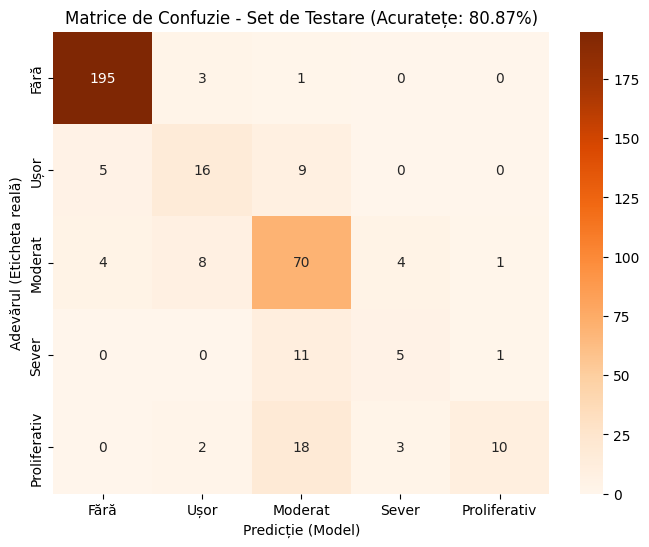


Raport de Clasificare:
                  precision    recall  f1-score   support

        Fără (0)       0.96      0.98      0.97       199
        Ușor (1)       0.55      0.53      0.54        30
     Moderat (2)       0.64      0.80      0.71        87
       Sever (3)       0.42      0.29      0.34        17
Proliferativ (4)       0.83      0.30      0.44        33

        accuracy                           0.81       366
       macro avg       0.68      0.58      0.60       366
    weighted avg       0.81      0.81      0.80       366



In [80]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- ÎNCEPE FAZA DE TESTARE ---")

# Încărcăm cel mai bun model
model.load_state_dict(torch.load('best_dr_model.pth'))
model.eval()

test_correct = 0
test_total = 0
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"\nAcuratețea finală pe setul de TEST: {test_acc:.2f}%\n")

# Calculăm Quadratic Weighted Kappa
qwk = cohen_kappa_score(test_labels, test_preds, weights='quadratic')
print(f"Scorul Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("(Un scor peste 0.7 este considerat bun în imagistica medicală)")

# Generarea Matricei de Confuzie
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Fără', 'Ușor', 'Moderat', 'Sever', 'Proliferativ'], 
            yticklabels=['Fără', 'Ușor', 'Moderat', 'Sever', 'Proliferativ'])
plt.xlabel('Predicție (Model)')
plt.ylabel('Adevărul (Eticheta reală)')
plt.title(f'Matrice de Confuzie - Set de Testare (Acuratețe: {test_acc:.2f}%)')
plt.show()

# Raport detaliat (Precision, Recall, F1-Score)
print("\nRaport de Clasificare:")
print(classification_report(test_labels, test_preds, target_names=['Fără (0)', 'Ușor (1)', 'Moderat (2)', 'Sever (3)', 'Proliferativ (4)']))

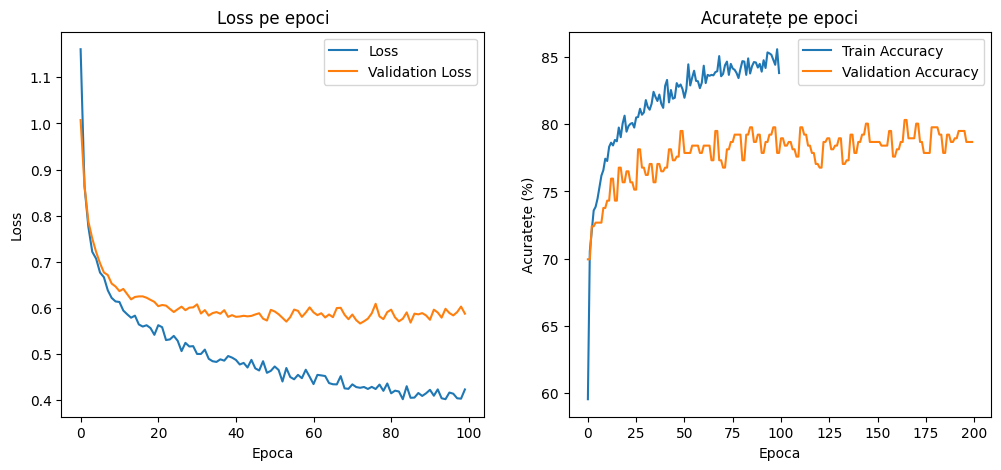

In [83]:
# Grafice pentru loss + acuratețe
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss pe epoci')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acuratețe pe epoci')
plt.xlabel('Epoca')
plt.ylabel('Acuratețe (%)')
plt.legend()
plt.show()

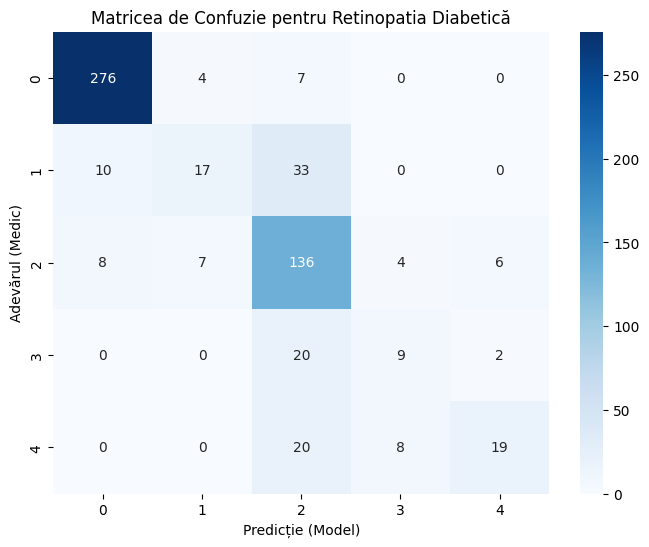

              precision    recall  f1-score   support

        Fără       0.94      0.96      0.95       287
        Ușor       0.61      0.28      0.39        60
     Moderat       0.63      0.84      0.72       161
       Sever       0.43      0.29      0.35        31
Proliferativ       0.70      0.40      0.51        47

    accuracy                           0.78       586
   macro avg       0.66      0.56      0.58       586
weighted avg       0.77      0.78      0.76       586



In [82]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generarea matricei de confuzie
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel('Predicție (Model)')
plt.ylabel('Adevărul (Medic)')
plt.title('Matricea de Confuzie pentru Retinopatia Diabetică')
plt.show()

# Raport detaliat
print(classification_report(all_labels, all_preds, target_names=['Fără', 'Ușor', 'Moderat', 'Sever', 'Proliferativ']))